# Neural ODE operator 

### Intuitive idea
We can view a residual neural network as the following process:$$y_{n+1} = y_n + f(y_n, \theta) \quad \forall n$$for a certain function $f$, which depends on both the state of each layer and the parameters. If we set $\Delta t = 1$, the expression above is an approximation of time step $1$ via the Euler method for the differential equation:$$\frac{dy}{dt} = f(y(t), \theta)$$Therefore, if we calculate the forward step, computing an initial state $y_0$ to a final state $y_{F}$ using the differential equation, then we will simulate a neural network with **continuous depth**.

### Rigorous Derivation of the Backward Process using Lagrangian Theory in Hilbert Spaces

To derive the gradient computation in Neural ODEs from optimal control theory, we formulate the problem within the framework of infinite-dimensional calculus of variations.

#### 1. Definition of the Functional Spaces

Let $z(t) \in \mathbb{R}^d$ be the latent state and $\theta \in \mathbb{R}^m$ the neural network parameters. To set up the problem in Hilbert spaces, we define:

*   **State Space ($\mathcal{Z}$):** For the time derivative and the weak formulation to be well-defined, the state must belong to the Sobolev space $W^{1,2}([t_0, t_1]; \mathbb{R}^d)$, frequently denoted as $H^1$. 
*   **Parameter Space ($\Theta$):** $\theta \in \mathbb{R}^m$, equipped with the standard Euclidean inner product.
*   **Constraint Space ($\mathcal{Y}$):** Assuming $f$ is Lipschitz continuous, the residual of the dynamic differential operator belongs to the space of square-integrable functions $\mathcal{Y} = L^2([t_0, t_1]; \mathbb{R}^d)$.
*   **Adjoint State Space ($\mathcal{Y}^*$):** The Lagrange multiplier (adjoint state) $a(t)$ is a continuous linear functional over $\mathcal{Y}$. By the Riesz Representation Theorem, we isometrically identify its dual space as $\mathcal{Y}^* \cong L^2([t_0, t_1]; \mathbb{R}^d)$.

#### 2. The Lagrangian Functional

The problem consists of minimizing a terminal cost function $L(z(t_1))$ subject to the dynamic constraint $E(z, \theta) = \dot{z}(t) - f(z(t), t, \theta) = 0$. 

We construct the Lagrangian functional $\mathcal{L}: \mathcal{Z} \times \Theta \times \mathcal{Y}^* \to \mathbb{R}$ by employing the dual pairing (inner product in $L^2$) between the constraint and the multiplier:

$$ \mathcal{L}(z, \theta, a) = L(z(t_1)) - \langle a, E(z, \theta) \rangle_{L^2} $$
$$ \mathcal{L}(z, \theta, a) = L(z(t_1)) - \int_{t_0}^{t_1} a(t)^\top \Big( \dot{z}(t) - f(z(t), t, \theta) \Big) dt $$

#### 3. Optimality Conditions (Fréchet Derivatives)

We seek the critical points of the Lagrangian by requiring its directional Fréchet derivatives to vanish for any admissible perturbation.

**A. Derivative with respect to the multiplier (Recovery of the Forward ODE):**
Perturbing in the direction of an arbitrary test function $\delta a \in L^2$:
$$ \partial_a \mathcal{L}[\delta a] = - \int_{t_0}^{t_1} \delta a(t)^\top \Big( \dot{z}(t) - f(z(t), t, \theta) \Big) dt = 0 \quad \forall \delta a \in L^2 $$
By the Fundamental Lemma of Calculus of Variations, this ensures that $\dot{z}(t) = f(z(t), t, \theta)$ holds almost everywhere.

**B. Derivative with respect to the state (Adjoint Equation):**
We differentiate $\mathcal{L}$ with respect to $z$ in the direction of an admissible variation $h \in H^1$ with a null initial condition $h(t_0) = 0$:
$$ \partial_z \mathcal{L}[h] = \nabla_z L(z(t_1))^\top h(t_1) - \int_{t_0}^{t_1} a(t)^\top \left( \dot{h}(t) - \frac{\partial f}{\partial z} h(t) \right) dt = 0 $$

To isolate $h(t)$, we apply integration by parts. Mathematically, this reveals the weak derivative of the functional $a(t)$, promoting it via a gain of regularity from the $L^2$ space to the Sobolev space $H^1$:
$$ \int_{t_0}^{t_1} a(t)^\top \dot{h}(t) dt = a(t_1)^\top h(t_1) - \underbrace{a(t_0)^\top h(t_0)}_{=0} - \int_{t_0}^{t_1} \dot{a}(t)^\top h(t) dt $$

Substituting this into the variational equation and grouping the terms associated with $h(t)$ and $h(t_1)$:
$$ 0 = \left( \nabla_z L(z(t_1)) - a(t_1) \right)^\top h(t_1) + \int_{t_0}^{t_1} \left( \dot{a}(t)^\top + a(t)^\top \frac{\partial f}{\partial z} \right) h(t) dt $$

Since $h(t)$ and the boundary value $h(t_1)$ are independent, their coefficients must vanish, thereby defining the full dynamics of the adjoint state:
1. **Transversality condition:** $a(t_1) = \nabla_z L(z(t_1))$
2. **Adjoint differential equation:** $\dot{a}(t) = - \left( \frac{\partial f}{\partial z} \right)^\top a(t)$

**C. Derivative with respect to parameters (Gradient Computation):**
Finally, we evaluate the Fréchet derivative of the Lagrangian with respect to $\theta$ in the direction $\delta \theta \in \mathbb{R}^m$, assuming the optimality conditions for $z$ and $a$ are already satisfied:
$$ \partial_\theta \mathcal{L}[\delta \theta] = \int_{t_0}^{t_1} a(t)^\top \frac{\partial f}{\partial \theta} \delta \theta dt $$

From this linear expression, we extract the exact gradient vector $\nabla_\theta L$ that will be propagated to the optimizer (e.g., Adam or SGD):
$$ \nabla_\theta L = \int_{t_0}^{t_1} \left( \frac{\partial f}{\partial \theta} \right)^\top a(t) dt $$

<!-- **Algorithm** Reverse-mode derivative of an ODE initial value problem

---

**Input:** dynamics parameters $\theta$, start time $t_0$, stop time $t_1$, final state $\mathbf{z}(t_1)$, loss gradient $\partial L/\partial \mathbf{z}(t_1)$

$s_0 = \left[\mathbf{z}(t_1), \frac{\partial L}{\partial \mathbf{z}(t_1)}, \mathbf{0}_{\vert{}\theta\vert{}}\right]$ $\quad \triangleright$ Define initial augmented state

**Backward process** compute [$z(t_0)$, $\nabla_z L(z(t_0))$, $\nabla_{\theta}L$] solving the reverse-time ODE 
$$
\begin{cases}
    z'(t) = f(z(t), \theta) & t \in [t_0, t_1] \\
    a'(t) = - \left( \frac{\partial f}{\partial z} \right)^\top a(t) & t \in [t_0, t_1]
    w'(t) = 


\end{cases}
$$

--- -->

**Algorithm** Reverse-mode derivative of an ODE initial value problem

---

**Input:** dynamics parameters $\theta$, start time $t_0$, stop time $t_1$, final state $\mathbf{z}(t_1)$, loss gradient $\partial L/\partial \mathbf{z}(t_1)$


**Backward process:** calculate [$\mathbf{z}(t_0)$, $a(t_0) = \nabla_z L(\mathbf{z}(t_0))$, $w(t_0) = \nabla_{\theta}L(\mathbf{z}(t_0)$] solving the reverse-time ODE
$$
\begin{cases}
    \mathbf{z}'(t) = f(\mathbf{z}(t), \theta), & \forall t \in [t_0,t_1], \\
    a'(t) = - \left( \frac{\partial f}{\partial z} \right)^\top a(t), & \forall t \in [t_0,t_1], \\
    w'(t) = - \left( \frac{\partial f}{\partial \theta} \right)^\top a(t), & \forall t \in [t_0,t_1], \\
    \mathbf{z}(t_1) = \mathbf{z}(t_1) \\
    a(t_1) = \nabla_z L(\mathbf{z}(t_1)) \\
    w(t_1) = 0 \\
\end{cases}
$$

---

## Neural ODEs for supervised learning


### Neural ODEs for Supervised Classification: Pros and Cons

#### Virtues 

*   **Extreme Parametric Efficiency:** By modeling the network as a non-autonomous dynamical system $\frac{dz}{dt} = f(z, t, \theta)$, the parameters $\theta$ are shared across the entire trajectory (the entire "depth"). A Neural ODE can achieve the representational capacity of a deep ResNet using a **fraction of the parameters**, significantly reducing the risk of **overfitting**.

*   **$\mathcal{O}(1)$ Memory Cost:** Thanks to Lagrangian multiplier theory and the adjoint state method, training does not require storing intermediate activations during the forward pass. This allows for training models with theoretically infinite "depth" without exceeding GPU VRAM limits.

#### Flaws 

*   **Topological Constraints (Picard-Lindelöf Theorem):** This is the most severe mathematical limitation. Since the vector field $f$ is continuous and locally Lipschitz, the Existence and Uniqueness Theorem strictly forbids trajectories from crossing in the phase space. This means a standard Neural ODE cannot learn mappings that require parity transformations (e.g., mapping $1 \mapsto -1$ and $-1 \mapsto 1$ in $\mathbb{R}^1$). The learned homeomorphism preserves the input topology, making it difficult to separate intricately intertwined classes without increasing the dimensionality (a problem solved by **Augmented Neural ODEs**).

*   **Numerical Instability in the Backward Pass:** The adjoint differential equation assumes the original trajectory can be perfectly integrated backwards in time. If the learned ODE has strongly **dissipative dynamics** (attractors that compress phase-space volume), the backward integration from $t_1$ to $t_0$ becomes **highly unstable**. This loses track of the initial state and generates inaccurate gradients, which can derail the training process.

*   **Inefficiency on Purely Static Data:** If the dataset lacks a sequential or continuous nature (e.g., static image classification), imposing the inductive bias of a continuous flow is computationally inefficient. Modern CNNs or Vision Transformers (ViTs) extract spatial features much more directly and in parallel, usually outperforming ODEs on these tasks.

### Simple implementation 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchdiffeq import odeint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

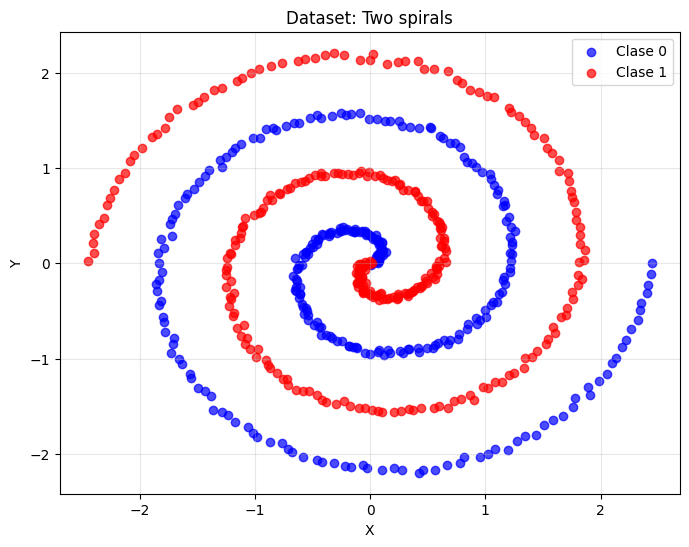

In [2]:
# ============================================
# 2.1 Gemerate the data
# ============================================

def generate_spiral_data(n_points=300, noise=0.1):
    # spiral 1 (class 0)
    t = np.linspace(0, 4*np.pi, n_points)
    x1 = t * np.cos(t) + np.random.randn(n_points) * noise
    y1 = t * np.sin(t) + np.random.randn(n_points) * noise
    
    # spiral 2 (class 1)
    x2 = t * np.cos(t + np.pi) + np.random.randn(n_points) * noise
    y2 = t * np.sin(t + np.pi) + np.random.randn(n_points) * noise
    
    # Combining 
    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
    y = np.hstack([np.zeros(n_points), np.ones(n_points)])
    
    # Standardize
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    
    return X.astype(np.float32), y.astype(np.int64)

X, y = generate_spiral_data(n_points=300, noise=0.1)


# ============================================
# 2.2 DATA PLOT
# ============================================

plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', alpha=0.7, label='Clase 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', alpha=0.7, label='Clase 1')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset: Two spirals')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# ============================================
# 3.1 DATASET
# ============================================

class SpiralDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ============================================
# 3.2 SPLIT THE DATA
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# 3.3 DATALOADERS
# ============================================

train_dataset = SpiralDataset(X_train, y_train)
test_dataset = SpiralDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
# ============================================
# 4.1 VECTOR FIELD
# ============================================

class ODEFunc(nn.Module):
    def __init__(self, hidden_dim):
        super(ODEFunc, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, hidden_dim)
        )
        
        # Initialization for stability
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.5)
                nn.init.constant_(m.bias, val=0)
    
    def forward(self, t, h):
        """
        Args:
            t: time (scalar)
            h: latent space [batch_size, hidden_dim]
        
        Returns:
            dh/dt: [batch_size, hidden_dim]
        """
        return self.net(h)

# ============================================
# 4.2 MODEL ARCHITECTURE
# ============================================

class NeuralODE_Classifier(nn.Module):
    """
    1. Encoder: (x, y) -> h(0)
    2. ODE: h(0) -> h(T) (time evolution)
    3. Classifier: h(T) -> logits (classes)
    """
    def __init__(self, input_dim=2, hidden_dim=64, num_classes=2, solver='dopri5'):
        super(NeuralODE_Classifier, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.solver = solver
        
        # 1. ENCODER: (x, y) -> latent space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, hidden_dim),
            nn.Tanh()
        )
        
        # 2. ODE: dh/dt = f(h, t)
        self.ode_func = ODEFunc(hidden_dim)
        
        # 3. CLASSIFIER: h(T) -> logits
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x, t_eval):
        """
        Args:
            x: [batch_size, input_dim] (initial point)
            t_eval: [num_times] (times)
        
        Returns:
            logits: [batch_size, num_classes]
            h_t: [num_times, batch_size, hidden_dim]
        """
        # 1. Encoder
        h0 = self.encoder(x)  # [batch_size, hidden_dim]
        
        # 2. Solving the ODE
        h_t = odeint(
            self.ode_func,
            h0,
            t_eval,
            method=self.solver,
            rtol=1e-3,
            atol=1e-4
        )  # [num_times, batch_size, hidden_dim]
        
        # 3. Obtain the final state
        h_final = h_t[-1]  # [batch_size, hidden_dim]
        
        # 4. Classifier 
        logits = self.classifier(h_final)  # [batch_size, num_classes]
        
        return logits, h_t

In [7]:
# ============================================
# 5.1 TRAINNING FUNCTIONS
# ============================================

def train_epoch(model, dataloader, optimizer, loss_fn, device, t_eval):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        
        # Forward pass
        logits, _ = model(X, t_eval)
        loss = loss_fn(logits, y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Data features
        total_loss += loss.item()
        _, predicted = logits.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy

# ============================================
# 5.2 EVALUATING FUNCTION
# ============================================

def evaluate(model, dataloader, loss_fn, device, t_eval):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            
            logits, _ = model(X, t_eval)
            loss = loss_fn(logits, y)
            
            total_loss += loss.item()
            _, predicted = logits.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy


In [8]:
# ============================================
# 6.1 DEFINE AND TRAIN THE MODEL
# ============================================

# Device
device = torch.device("cuda")

# Crear modelo
model = NeuralODE_Classifier(
    input_dim=2,
    hidden_dim=64,
    num_classes=2,
    solver='dopri5'  
).to(device)


# Optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Times
t_eval = torch.linspace(0, 1, 20).to(device)

# ============================================
# 6.2 TRAINNING
# ============================================

num_epochs = 50
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print("\n" + "=" * 60)
print("START OF TRAINING")
print("=" * 60)

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, loss_fn, device, t_eval
    )
    
    # Evaluate
    test_loss, test_acc = evaluate(
        model, test_loader, loss_fn, device, t_eval
    )
    
    # Save features
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Época {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Test Acc: {test_acc:.2f}%")

print("\n" + "=" * 60)
print("TRAINNING COMPLETED ")
print("=" * 60)



START OF TRAINING
Época   1/50 | Train Loss: 0.6923 | Train Acc: 53.33% | Test Acc: 58.33%
Época  10/50 | Train Loss: 0.6105 | Train Acc: 62.92% | Test Acc: 54.17%
Época  20/50 | Train Loss: 0.3606 | Train Acc: 81.67% | Test Acc: 82.50%
Época  30/50 | Train Loss: 0.1781 | Train Acc: 91.88% | Test Acc: 87.50%
Época  40/50 | Train Loss: 0.0864 | Train Acc: 96.46% | Test Acc: 94.17%
Época  50/50 | Train Loss: 0.2050 | Train Acc: 92.29% | Test Acc: 89.17%

TRAINNING COMPLETED 


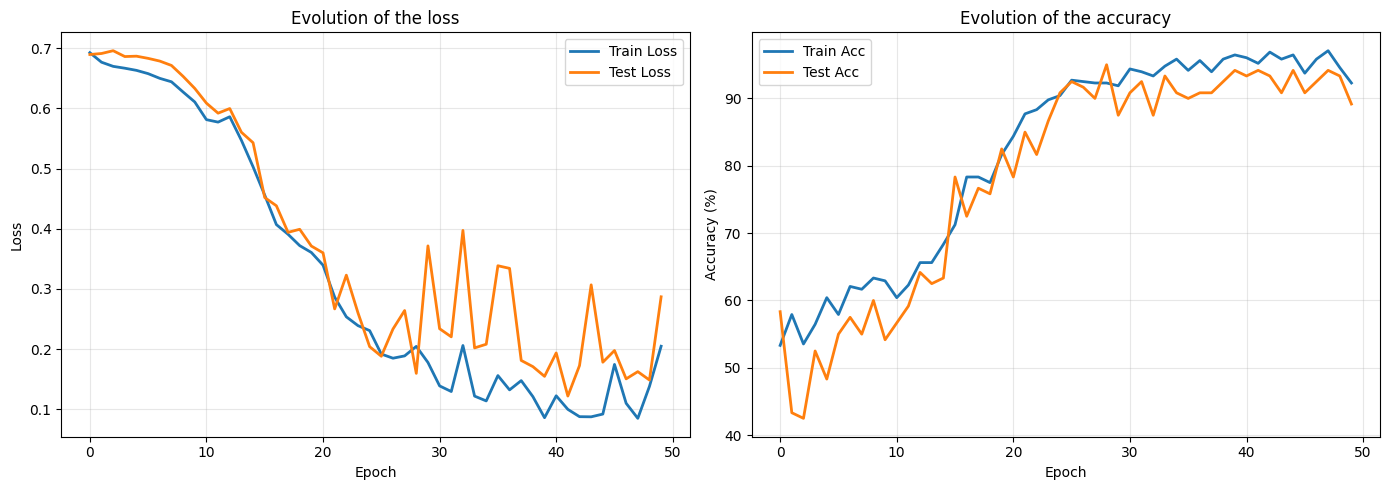

In [9]:
# ============================================
# 7.1 LEARNING CURVES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['test_loss'], label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Evolution of the loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Exactitud
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['test_acc'], label='Test Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Evolution of the accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




### Comparison with ResNet


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchdiffeq import odeint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import seaborn as sns
from datetime import datetime

torch.manual_seed(42)
np.random.seed(42)


# ============================================
# 1. Loading the data
# ============================================

# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) 
])

# Datasets
train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Dataloaders
batch_size = 128
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

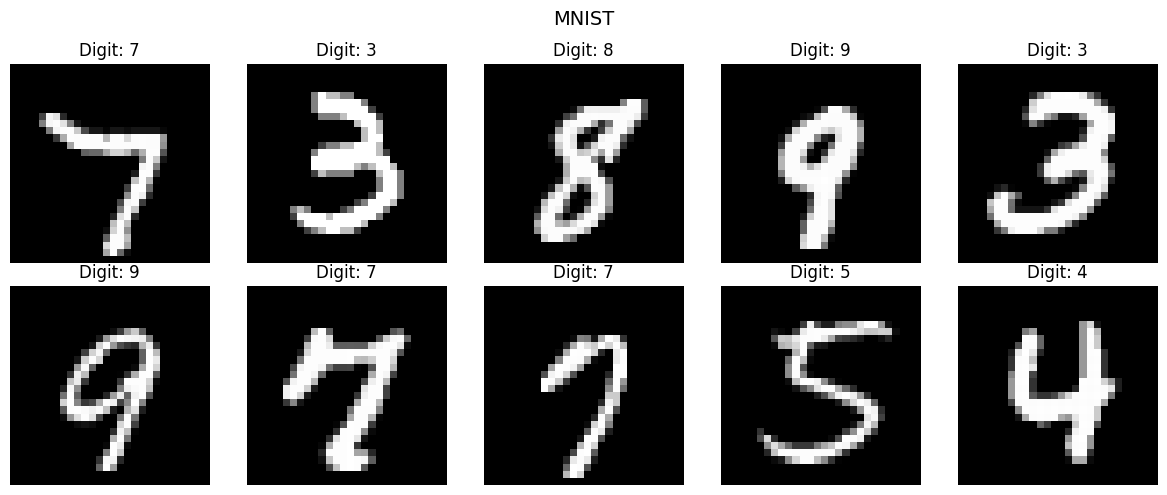

In [12]:
def show_mnist_samples(dataset, num_samples=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        img = img.squeeze().numpy()
        
        ax = axes[i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Digit: {label}')
        ax.axis('off')
    
    plt.suptitle('MNIST', fontsize=14)
    plt.tight_layout()
    plt.show()

show_mnist_samples(train_dataset)

In [13]:
# ============================================
# 3. NEURAL ODE ARCHITECTURE
# ============================================

class ODEFunc(nn.Module):
    def __init__(self, hidden_dim):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, hidden_dim)
        )
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.5)
                nn.init.constant_(m.bias, val=0)
    
    def forward(self, t, h):
        return self.net(h)

class NeuralODE_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, num_classes=10, solver='dopri5'):
        super(NeuralODE_MNIST, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.solver = solver
        
        # Encoder: Image -> latent state
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim),
            nn.Tanh()
        )
        
        # ODE Func
        self.ode_func = ODEFunc(hidden_dim)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x, t_eval):
        # x: [batch_size, 784]
        h0 = self.encoder(x)
        
        # Solving the ODE
        h_t = odeint(
            self.ode_func, 
            h0, 
            t_eval, 
            method=self.solver,
            rtol=1e-3,
            atol=1e-4
        )
        
        h_final = h_t[-1]
        logits = self.classifier(h_final)
        
        return logits, h_t

In [14]:
# ============================================
# 4. RESNET ARCHITECTURE
# ============================================

class ResidualBlock(nn.Module):
    """
    Residual block
    """
    def __init__(self, hidden_dim):
        super(ResidualBlock, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, hidden_dim)
        )
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                nn.init.constant_(m.bias, val=0)
    
    def forward(self, x):
        return x + self.net(x)  # Conexión residual

class ResNet_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, num_blocks=6, num_classes=10):
        super(ResNet_MNIST, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_blocks = num_blocks
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim),
            nn.Tanh()
        )
        
        # Residual blocks
        self.res_blocks = nn.ModuleList([
            ResidualBlock(hidden_dim) for _ in range(num_blocks)
        ])
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        h = self.encoder(x)
        for block in self.res_blocks:
            h = block(h)
        logits = self.classifier(h)
        return logits

In [15]:
# ============================================
# 5. SUPPORT FUNCTIONS
# ============================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_epoch(model, dataloader, optimizer, loss_fn, device, t_eval=None, is_ode=True):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X, y in dataloader:
        X = X.view(X.size(0), -1).to(device)  
        y = y.to(device)
        
        optimizer.zero_grad()
        
        if is_ode:
            logits, _ = model(X, t_eval)
        else:
            logits = model(X)
        
        loss = loss_fn(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = logits.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    return total_loss / len(dataloader), 100. * correct / total

def evaluate(model, dataloader, device, t_eval=None, is_ode=True):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X, y in dataloader:
            X = X.view(X.size(0), -1).to(device)
            y = y.to(device)
            
            if is_ode:
                logits, _ = model(X, t_eval)
            else:
                logits = model(X)
            
            _, predicted = logits.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    accuracy = 100. * correct / total
    return accuracy, all_preds, all_labels

def train_model_complete(model, train_loader, test_loader, device, 
                         num_epochs=30, t_eval=None, is_ode=True, model_name="Modelo"):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epoch_times': []
    }
    
    best_acc = 0
    best_state = None
    
    print(f"\n{'='*60}")
    print(f"START THE TRAINNING: {model_name}")
    print(f"{'='*60}")
    print(f"Parameters: {count_parameters(model):,}")
    print(f"Epochs: {num_epochs}")
    print("-" * 40)
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, loss_fn, device, t_eval, is_ode
        )
        
        # Test
        test_acc, _, _ = evaluate(
            model, test_loader, device, t_eval, is_ode
        )
        
        epoch_time = time.time() - start_time
        
        # Save features
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['epoch_times'].append(epoch_time)
        
        # Scheduler
        scheduler.step(test_acc)
        
        # Save the best model
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = model.state_dict().copy()
        
        # Print the progesss
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Train Acc: {train_acc:.2f}% | "
                  f"Test Acc: {test_acc:.2f}% | "
                  f"Time required: {epoch_time:.2f}s")
    
    # Loading the best model
    if best_state is not None:
        model.load_state_dict(best_state)
    
    print(f"\Best Test Accuracy: {best_acc:.2f}%")
    print(f"Total time: {sum(history['epoch_times']):.2f}s")
    print(f"Mean time per epoch: {np.mean(history['epoch_times']):.2f}s")
    
    return model, history, best_acc

In [ ]:
device = torch.device("cuda")
# ============================================
# 7. TRAIN NEURAL ODE
# ============================================

# Times
t_eval = torch.linspace(0, 1, 10).to(device)

model_ode = NeuralODE_MNIST(
    input_dim=784,
    hidden_dim=128,
    num_classes=10,
    solver='dopri5'
).to(device)

model_ode, history_ode, best_acc_ode = train_model_complete(
    model_ode, train_loader, test_loader, device,
    num_epochs=20,  
    t_eval=t_eval, 
    is_ode=True, 
    model_name="NEURAL ODE"
)

# ============================================
# 8. TRAIN RESNET
# ============================================

model_resnet = ResNet_MNIST(
    input_dim=784,
    hidden_dim=128,
    num_blocks=6,
    num_classes=10
).to(device)

model_resnet, history_resnet, best_acc_resnet = train_model_complete(
    model_resnet, train_loader, test_loader, device,
    num_epochs=20,  
    t_eval=None, 
    is_ode=False, 
    model_name="RESNET"
)


START THE TRAINNING: NEURAL ODE
Parameters: 407,498
Epochs: 20
----------------------------------------
Epoch   1/20 | Train Loss: 0.4052 | Train Acc: 87.70% | Test Acc: 95.23% | Time required: 56.39s
Epoch   5/20 | Train Loss: 0.0810 | Train Acc: 97.61% | Test Acc: 97.81% | Time required: 45.77s
Epoch  10/20 | Train Loss: 0.0502 | Train Acc: 98.46% | Test Acc: 98.08% | Time required: 50.51s
Epoch  15/20 | Train Loss: 0.0220 | Train Acc: 99.34% | Test Acc: 98.27% | Time required: 58.19s


NameError: name 'history_ode' is not defined

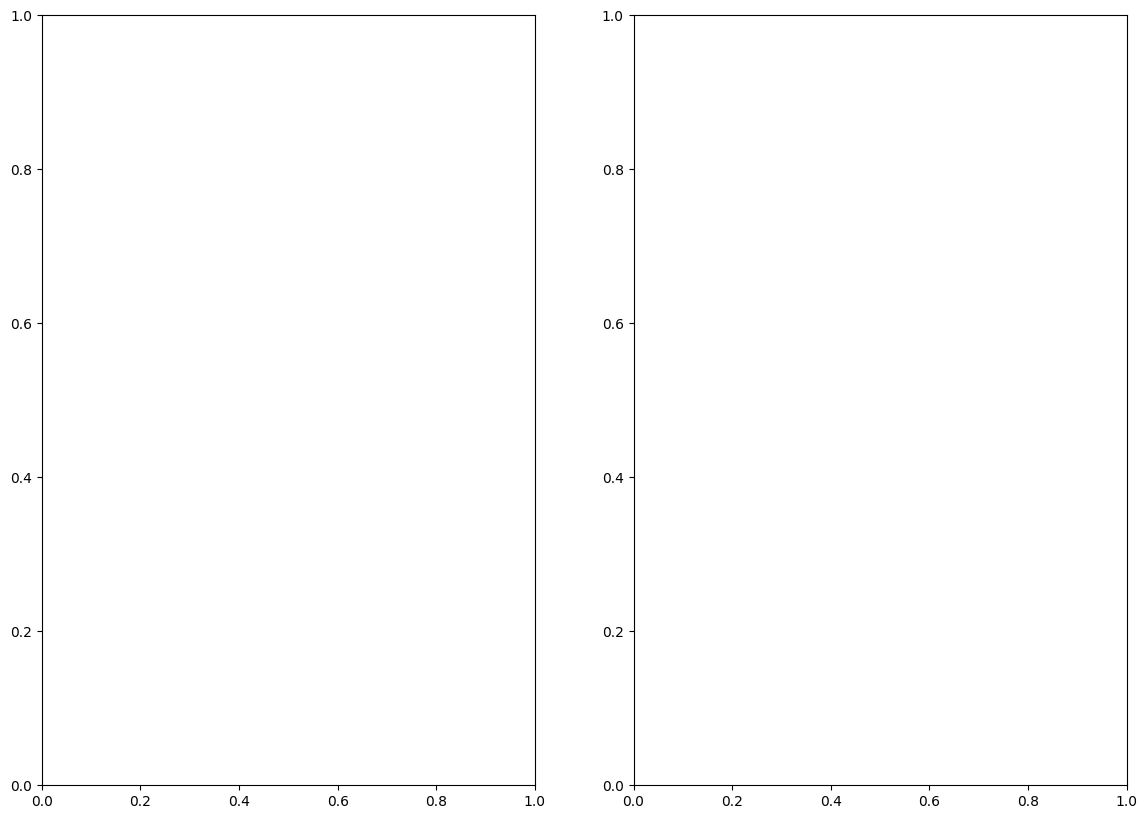

In [ ]:
# 11.1 LEARNING CURVES
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Accuracy
ax = axes[0]
ax.plot(history_ode['test_acc'], 'b-', linewidth=2, label='Neural ODE')
ax.plot(history_resnet['test_acc'], 'r-', linewidth=2, label='ResNet')
ax.axhline(y=best_acc_ode, color='blue', linestyle='--', alpha=0.5)
ax.axhline(y=best_acc_resnet, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MNIST')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(history_ode['train_loss'], 'b-', linewidth=2, label='Neural ODE')
ax.plot(history_resnet['train_loss'], 'r-', linewidth=2, label='ResNet')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('MNIST')
ax.legend()
ax.grid(True, alpha=0.3)

## Neural ODEs for Time Series Analysis

While traditional recurrent architectures (such as RNNs or LSTMs) inherently assume that time series data is collected at uniform, discrete intervals, real-world data is often irregularly sampled, asynchronous, or riddled with missing values. Neural ODEs offer a paradigm shift by modeling the latent state as a continuous-time dynamical system:

$$ \frac{dz(t)}{dt} = f(z(t), t, \theta) $$

Because the hidden state $z(t)$ is defined continuously for all $t$, the model can process observations at the exact timestamp they occur. This elegant mathematical formulation completely bypasses the need to discretize time, bin data into fixed windows, or rely on artificial imputation techniques.

#### Pros 

*   **Native Handling of Irregular Data:** Neural ODEs integrate seamlessly over arbitrary time gaps.

*   **Modeling Unknown Dynamics:** They excel at modeling physical, biological, or mechanical phenomena known to be governed by differential equations. They act as a powerful data-driven tool to approximate and simulate the system even when the explicit analytical expression of the underlying vector field is entirely unknown.

#### Cons 

*   **Stiffness and NFE Explosion:** As the model learns to map complex dynamics, the underlying vector field often becomes highly irregular and mathematically stiff. 


### Modeling a Chaotic System: The Lorenz Attractor

In this section, we will use a Neural ODE to model the dynamics of a classic chaotic system: the **Lorenz attractor**. 

This is a three-dimensional system of nonlinear ordinary differential equations that models, in a simplified manner, two-dimensional fluid flow and atmospheric convection. The time evolution of the state is governed by the following equations:

$$\frac{dx}{dt}=\sigma(y-x)$$
$$\frac{dy}{dt}=x(\rho-z)-y$$
$$\frac{dz}{dt}=xy-\beta z$$

Where $\sigma$, $\rho$, and $\beta$ are positive parameters of the system.

**Chaotic Nature of the System** 
A fundamental characteristic of the Lorenz attractor is that, for certain parameter values, the system is intrinsically chaotic. This implies an extreme sensitivity to initial conditions: infinitesimal changes in the starting point of a trajectory produce exponentially large differences in its evolution over time. 

This deterministic yet unpredictable behavior makes approximating its underlying vector field using a Neural ODE an excellent challenge to evaluate the neural network's capabilities.

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

#### Create the data

In [5]:
def lorenz_system(t, state, sigma=10, rho=28, beta=8/3):
    """
    Lorenz system differential equations.
    
    Args:
        t: time (not used explicitly, but required by solve_ivp)
        state: current state [x, y, z]
        sigma, rho, beta: system parameters
    
    Returns:
        derivatives [dx/dt, dy/dt, dz/dt]
    """
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

def generate_lorenz_data(n_sequences=1000, seq_len=100, dt=0.01):
    """
    Generate training data from the Lorenz system.
    
    For Neural ODE:
    - Input: initial state at time t=0
    - Output: full trajectory for all future times
    
    Args:
        n_sequences: number of different trajectories
        seq_len: length of each trajectory (number of time steps)
        dt: time step size
    
    Returns:
        X: initial states [n_sequences, 3]
        y: full trajectories [n_sequences, seq_len, 3]
        scaler_X: scaler for initial states
        scaler_y: scaler for trajectories
    """
    
    X = []  # Store initial states
    y = []  # Store full trajectories
    
    print(f"Generating {n_sequences} trajectories with {seq_len} steps each...")
    
    for i in range(n_sequences):
        # Random initial conditions within a reasonable range
        x0 = np.random.uniform(-10, 10, 3)
        
        # Define time span and evaluation points
        t_span = (0, seq_len * dt)
        t_eval = np.linspace(0, seq_len * dt, seq_len + 1)
        
        # Solve the Lorenz system using RK45
        sol = solve_ivp(
            lorenz_system, 
            t_span, 
            x0, 
            t_eval=t_eval, 
            method='RK45',
            rtol=1e-8,
            atol=1e-10
        )
        
        # Extract data: [seq_len+1, 3]
        data = sol.y.T
        
        # Input: initial state (first point)
        X.append(data[0])  # [3]
        
        # Output: full trajectory (all subsequent points)
        y.append(data[1:])  # [seq_len, 3]
    
    # Convert to numpy arrays
    X = np.array(X, dtype=np.float32)  # [n_sequences, 3]
    y = np.array(y, dtype=np.float32)  # [n_sequences, seq_len, 3]
    
    # Normalize initial states separately
    scaler_X = StandardScaler()
    X = scaler_X.fit_transform(X)
    
    # Normalize trajectories (flatten, scale, reshape)
    y_flat = y.reshape(-1, 3)
    scaler_y = StandardScaler()
    y_flat = scaler_y.fit_transform(y_flat)
    y = y_flat.reshape(-1, seq_len, 3)
    
    return X, y, scaler_X, scaler_y

In [6]:
# Generate the data
X, y, scaler_X, scaler_y = generate_lorenz_data(
    n_sequences=1000, 
    seq_len=100, 
    dt=0.02
)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X.shape

Generating 1000 trajectories with 100 steps each...


(1000, 3)

#### Create the dataset and dataloader

In [8]:
class LorenzDataset(Dataset):
    """
    PyTorch Dataset for Lorenz system data.
    
    Each sample consists of:
    - x0: initial state [3]
    - trajectory: full trajectory [seq_len, 3]
    """
    def __init__(self, X, y):
        """
        Args:
            X: initial states [n_samples, 3]
            y: full trajectories [n_samples, seq_len, 3]
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = LorenzDataset(X_train, y_train)
test_dataset = LorenzDataset(X_test, y_test)

# Create dataloaders
batch_size = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    drop_last=True
)


#### Definition of the neural ODE architecture 

In [ ]:
"""
The model consists of:
1. Encoder: maps input state to latent representation
2. ODE Function: learns the continuous dynamics dh/dt = f(h, t)
3. Decoder: maps latent state back to output
"""

class ODEFunc(nn.Module):
    """
    Neural network that defines the ODE dynamics: dh/dt = f(h, t)
    
    This is the core of the Neural ODE. It learns the vector field
    that governs the evolution of the latent state.
    """
    def __init__(self, hidden_dim):
        super(ODEFunc, self).__init__()
        
        self.hidden_dim = hidden_dim
        
        # Neural network for the vector field
        # Input: hidden state h (and optionally time t)
        # Output: derivative dh/dt
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, hidden_dim)
        )
        
        # Initialize weights for stability
        self._initialize_weights()
    
    def _initialize_weights(self):
        """
        Initialize weights with small values for numerical stability.
        Orthogonal initialization helps avoid exploding gradients.
        """
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.5)
                nn.init.constant_(m.bias, val=0)
    
    def forward(self, t, h):
        """
        Compute the derivative dh/dt at time t.
        
        Args:
            t: time (scalar, but unused if time-invariant)
            h: latent state [batch_size, hidden_dim]
        
        Returns:
            dh/dt: derivative [batch_size, hidden_dim]
        """
        return self.net(h)

class NeuralODELorenz(nn.Module):
    """
    Neural ODE for predicting Lorenz system trajectories.
    
    Given an initial state, the model predicts the full trajectory
    by solving the learned ODE.
    
    Architecture:
    1. Encoder: maps input state (3D) to latent space (hidden_dim)
    2. ODE: evolves latent state continuously in time
    3. Decoder: maps latent state back to output (3D)
    """
    def __init__(self, input_dim=3, hidden_dim=64, output_dim=3, solver='dopri5'):
        """
        Args:
            input_dim: dimension of input state (3 for Lorenz)
            hidden_dim: dimension of latent state
            output_dim: dimension of output (3 for Lorenz)
            solver: ODE solver method ('dopri5', 'rk4', 'euler')
        """
        super(NeuralODELorenz, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.solver = solver
        
        # ============================================
        # 1. ENCODER: input -> latent state
        # ============================================
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim),
            nn.Tanh()  # Bound the latent state
        )
        
        # ============================================
        # 2. ODE FUNCTION: learns dh/dt = f(h, t)
        # ============================================
        self.ode_func = ODEFunc(hidden_dim)
        
        # ============================================
        # 3. DECODER: latent state -> output
        # ============================================
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
        
        print(f"Model initialized with {self.count_parameters():,} parameters")
    
    def forward(self, x0, t_eval):
        """
        Predict the full trajectory given an initial state.
        
        Args:
            x0: initial state [batch_size, input_dim]
            t_eval: times at which to evaluate [num_times]
        
        Returns:
            pred: predicted trajectory [batch_size, num_times, output_dim]
            h_t: latent trajectory [num_times, batch_size, hidden_dim]
        """
        batch_size = x0.shape[0]
        
        # ============================================
        # Step 1: Encode initial state to latent space
        # ============================================
        h0 = self.encoder(x0)  # [batch_size, hidden_dim]
        
        # ============================================
        # Step 2: Solve the ODE (continuous evolution)
        # ============================================
        # The ODE solver integrates dh/dt = f(h, t) from t=0 to t=T
        h_t = odeint(
            self.ode_func,      # Function defining dh/dt
            h0,                 # Initial condition
            t_eval,             # Times to evaluate
            method=self.solver, # ODE solver method
            rtol=1e-3,         # Relative tolerance
            atol=1e-4          # Absolute tolerance
        )  # [num_times, batch_size, hidden_dim]
        
        # ============================================
        # Step 3: Decode latent states to outputs
        # ============================================
        # Decode each time step
        pred = []
        for t in range(len(t_eval)):
            h_t_curr = h_t[t]  # [batch_size, hidden_dim]
            pred_t = self.decoder(h_t_curr)  # [batch_size, output_dim]
            pred.append(pred_t)
        
        # Stack predictions
        pred = torch.stack(pred, dim=1)  # [batch_size, num_times, output_dim]
        
        return pred, h_t

#### Training and testing functions

In [ ]:
def count_parameters(model):
    """Count the number of trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_epoch(model, dataloader, optimizer, loss_fn, device, t_eval):
    """
    Train the model for one epoch.
    
    Args:
        model: Neural ODE model
        dataloader: DataLoader with training data
        optimizer: Optimizer for updating weights
        loss_fn: Loss function (MSE)
        device: Device to use ('cuda' or 'cpu')
        t_eval: Times at which to evaluate the ODE
    
    Returns:
        avg_loss: Average loss for this epoch
    """
    model.train()
    total_loss = 0
    n_batches = 0
    
    for batch_idx, (x0, y_true) in enumerate(dataloader):
        # Move data to device
        x0 = x0.to(device)          # [batch_size, 3]
        y_true = y_true.to(device)  # [batch_size, seq_len, 3]
        
        batch_size, seq_len, _ = y_true.shape
        
        # ============================================
        # Forward pass: predict trajectory
        # ============================================
        # Given initial state x0, predict all future states
        pred, _ = model(x0, t_eval)  # [batch_size, num_times, 3]
        
        # Truncate predictions to match the sequence length
        pred = pred[:, :seq_len, :]  # [batch_size, seq_len, 3]
        
        # ============================================
        # Compute loss
        # ============================================
        loss = loss_fn(pred, y_true)
        
        # ============================================
        # Backward pass
        # ============================================
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Accumulate loss
        total_loss += loss.item()
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    return avg_loss

def evaluate(model, dataloader, loss_fn, device, t_eval):
    """
    Evaluate the model on test/validation data.
    
    Args:
        model: Neural ODE model
        dataloader: DataLoader with evaluation data
        loss_fn: Loss function (MSE)
        device: Device to use ('cuda' or 'cpu')
        t_eval: Times at which to evaluate the ODE
    
    Returns:
        avg_loss: Average loss
        predictions: All predictions
        targets: All targets
    """
    model.eval()
    total_loss = 0
    n_batches = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x0, y_true in dataloader:
            # Move data to device
            x0 = x0.to(device)
            y_true = y_true.to(device)
            
            batch_size, seq_len, _ = y_true.shape
            
            # Forward pass
            pred, _ = model(x0, t_eval)
            pred = pred[:, :seq_len, :]
            
            # Compute loss
            loss = loss_fn(pred, y_true)
            
            total_loss += loss.item()
            n_batches += 1
            
            # Store predictions and targets
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y_true.cpu().numpy())
    
    avg_loss = total_loss / n_batches
    
    # Concatenate all predictions and targets
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    return avg_loss, all_preds, all_targets

def train_model(model, train_loader, test_loader, device, t_eval, 
                num_epochs=50, lr=1e-3):
    """
    Full training loop for the Neural ODE model.
    
    Args:
        model: Neural ODE model
        train_loader: Training DataLoader
        test_loader: Test DataLoader
        device: Device to use
        t_eval: Times for ODE evaluation
        num_epochs: Number of training epochs
        lr: Learning rate
    
    Returns:
        model: Trained model
        history: Training history
    """
    # ============================================
    # Setup optimizer and loss function
    # ============================================
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=5
    )
    loss_fn = nn.MSELoss()
    
    # ============================================
    # Training history
    # ============================================
    history = {
        'train_loss': [],
        'test_loss': [],
        'epoch_times': []
    }
    
    best_test_loss = float('inf')
    best_model_state = None
    
    print("\n" + "=" * 60)
    print("STARTING TRAINING")
    print("=" * 60)
    print(f"Device: {device}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate: {lr}")
    print(f"Model parameters: {count_parameters(model):,}")
    print("=" * 60)
    
    # ============================================
    # Training loop
    # ============================================
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)
        
        # Train
        train_loss = train_epoch(
            model, train_loader, optimizer, loss_fn, device, t_eval
        )
        
        # Evaluate
        test_loss, _, _ = evaluate(
            model, test_loader, loss_fn, device, t_eval
        )
        
        epoch_time = time.time() - epoch_start_time
        
        # Update scheduler
        scheduler.step(test_loss)
        
        # Save best model
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_model_state = model.state_dict().copy()
            print(f"  ✓ New best model! Test Loss: {test_loss:.6f}")
        
        # Store history
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['epoch_times'].append(epoch_time)

        
        
        # Print summary
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Test Loss:  {test_loss:.6f}")
        print(f"  Time:       {epoch_time:.2f}s")
        print(f"  LR:         {optimizer.param_groups[0]['lr']:.6f}")
    
    # ============================================
    # Load best model
    # ============================================
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Loaded best model with Test Loss: {best_test_loss:.6f}")
    
    print("\n" + "=" * 60)
    print("TRAINING COMPLETED")
    print("=" * 60)
    
    return model, history

#### Create and train the model

In [13]:
# ============================================
# Setup device
# ============================================
device = torch.device("cuda")

# ============================================
# Create model
# ============================================
model = NeuralODELorenz(
    input_dim=3,
    hidden_dim=64,
    output_dim=3,
    solver='dopri5'  # 'dopri5', 'rk4', or 'euler'
).to(device)

# ============================================
# Define evaluation times
# ============================================
# We want to predict 100 time steps from the initial state
seq_len = y_train.shape[1]  # 100
t_eval = torch.linspace(0, 1, seq_len).to(device)  # [0, 0.01, 0.02, ..., 1.0]

# ============================================
# Train the model
# ============================================
model, history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    t_eval=t_eval,
    num_epochs=30,
    lr=1e-3
)

Model initialized with 66,691 parameters

STARTING TRAINING
Device: cuda
Epochs: 30
Learning rate: 0.001
Model parameters: 66,691

Epoch 1/30
----------------------------------------
  ✓ New best model! Test Loss: 0.914294
  Train Loss: 0.969063
  Test Loss:  0.914294
  Time:       5.16s
  LR:         0.001000

Epoch 2/30
----------------------------------------
  ✓ New best model! Test Loss: 0.808591
  Train Loss: 0.837290
  Test Loss:  0.808591
  Time:       4.57s
  LR:         0.001000

Epoch 3/30
----------------------------------------
  ✓ New best model! Test Loss: 0.729974
  Train Loss: 0.756047
  Test Loss:  0.729974
  Time:       4.62s
  LR:         0.001000

Epoch 4/30
----------------------------------------
  ✓ New best model! Test Loss: 0.679706
  Train Loss: 0.689531
  Test Loss:  0.679706
  Time:       5.29s
  LR:         0.001000

Epoch 5/30
----------------------------------------
  ✓ New best model! Test Loss: 0.591953
  Train Loss: 0.631868
  Test Loss:  0.591953
  T

#### Plot results


VISUALIZING RESULTS

1. Plotting training history...


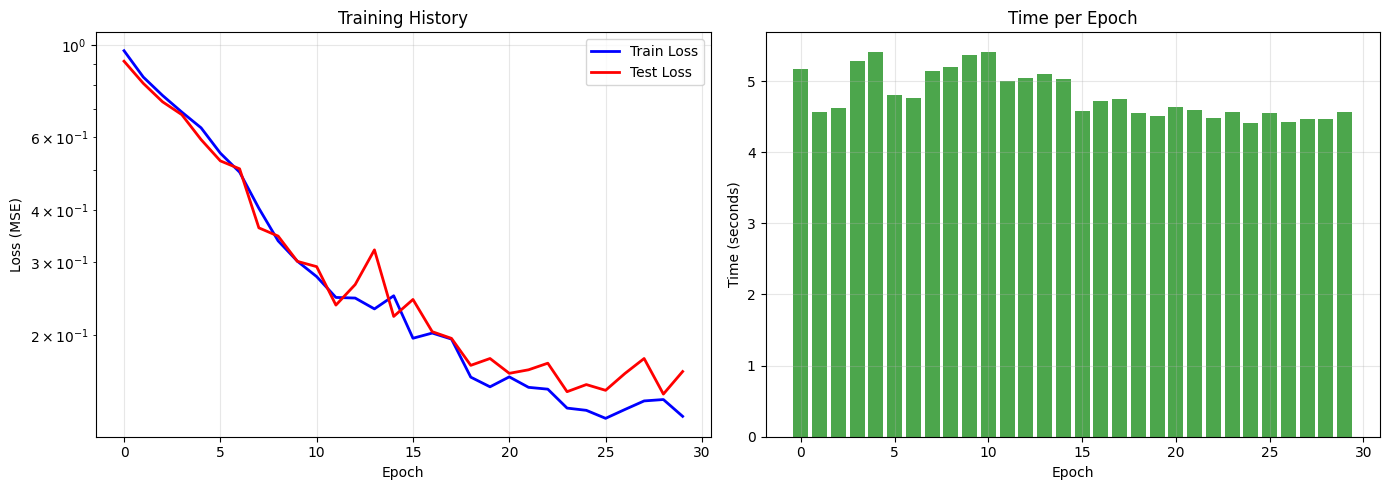


2. Plotting example predictions...


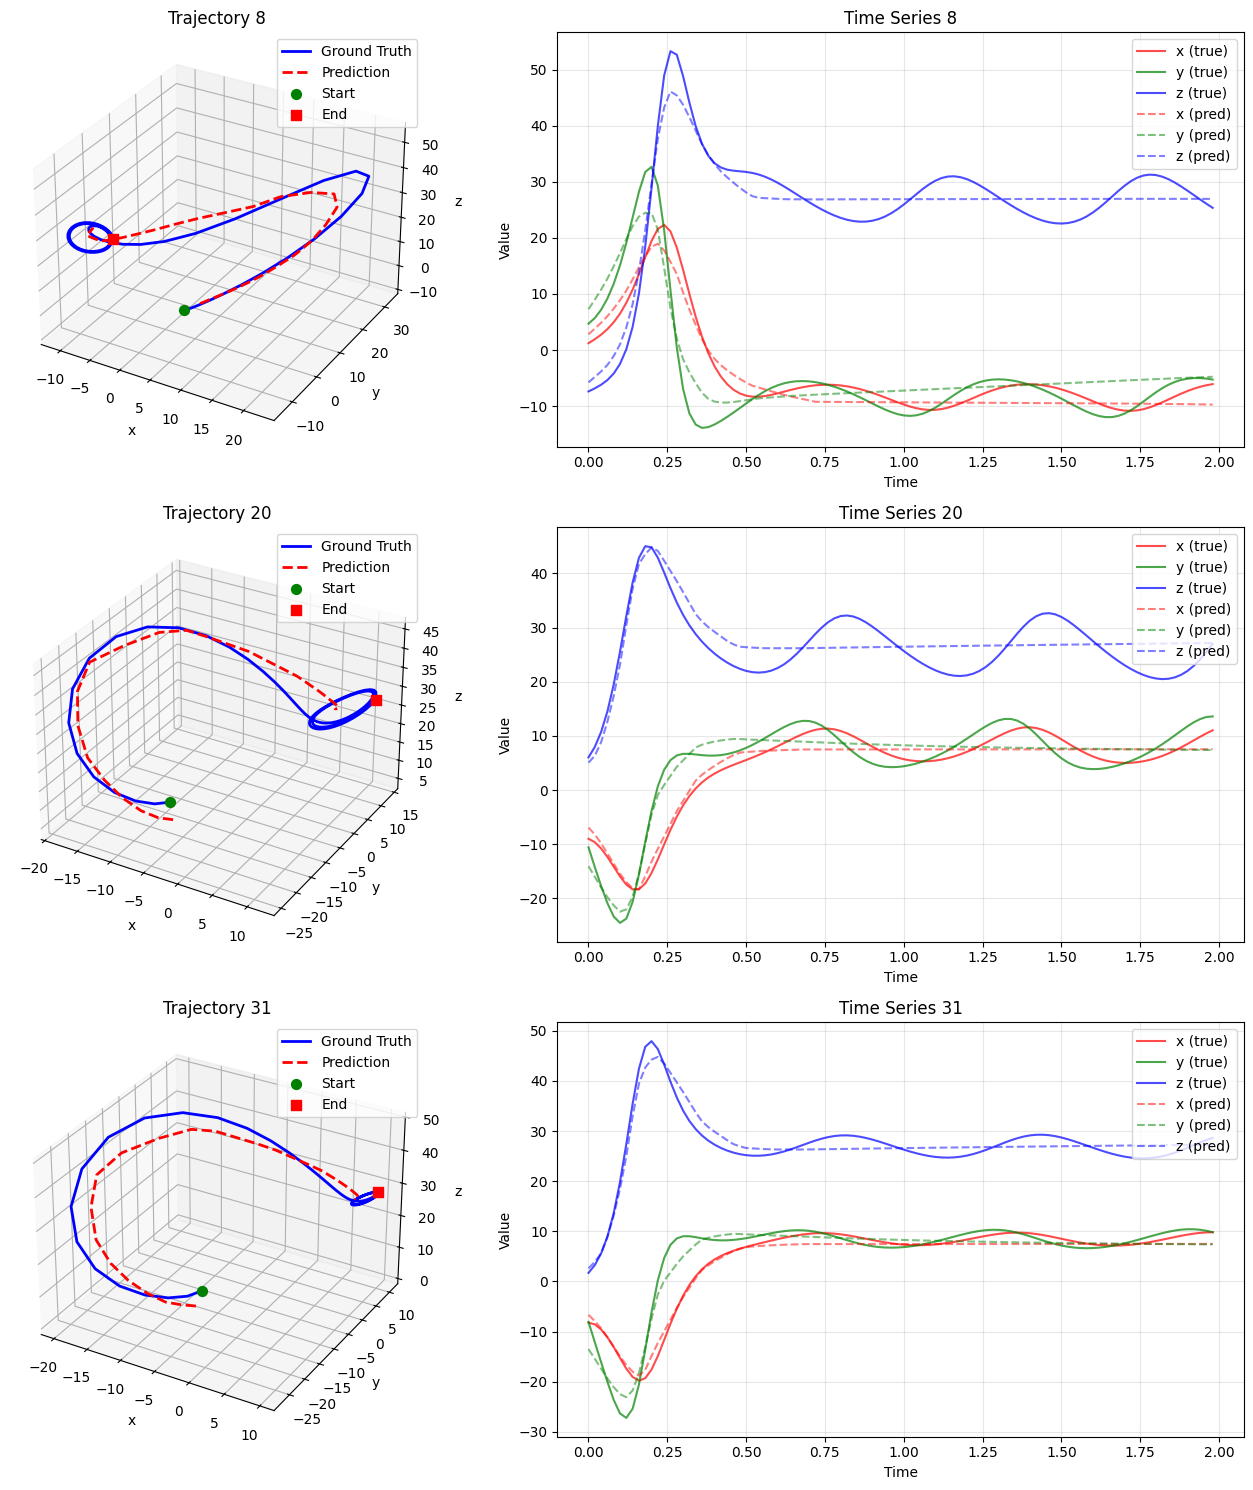


3. Plotting error analysis...


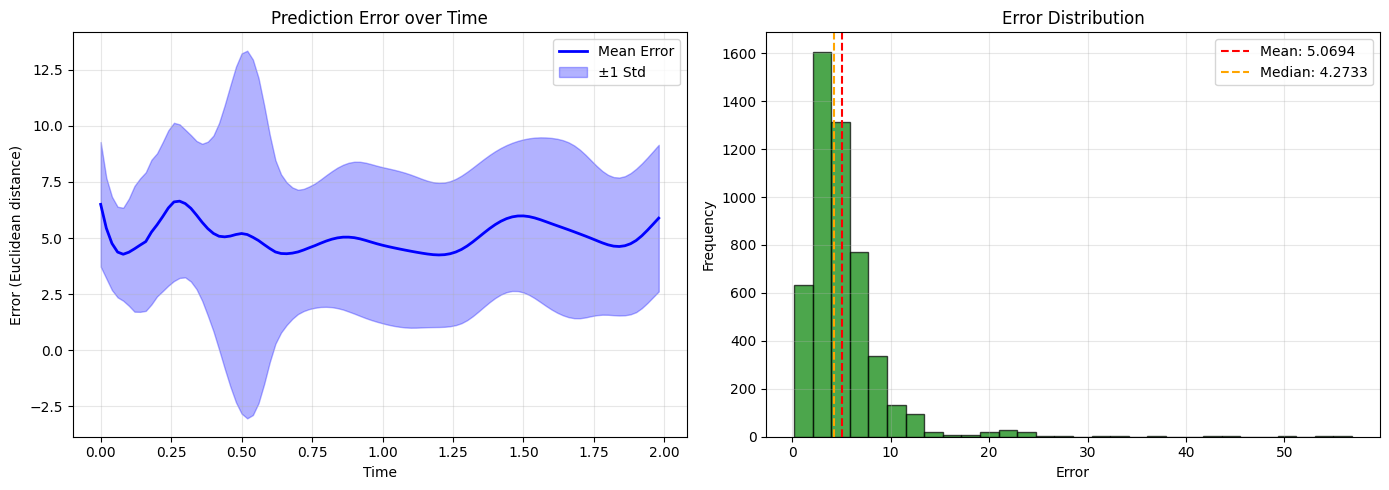


Error Statistics:
  Mean Error: 5.069396
  Std Error:  3.854676
  Min Error:  0.204648
  Max Error:  56.866009
  Median:     4.273272

4. Plotting 3D comparison...


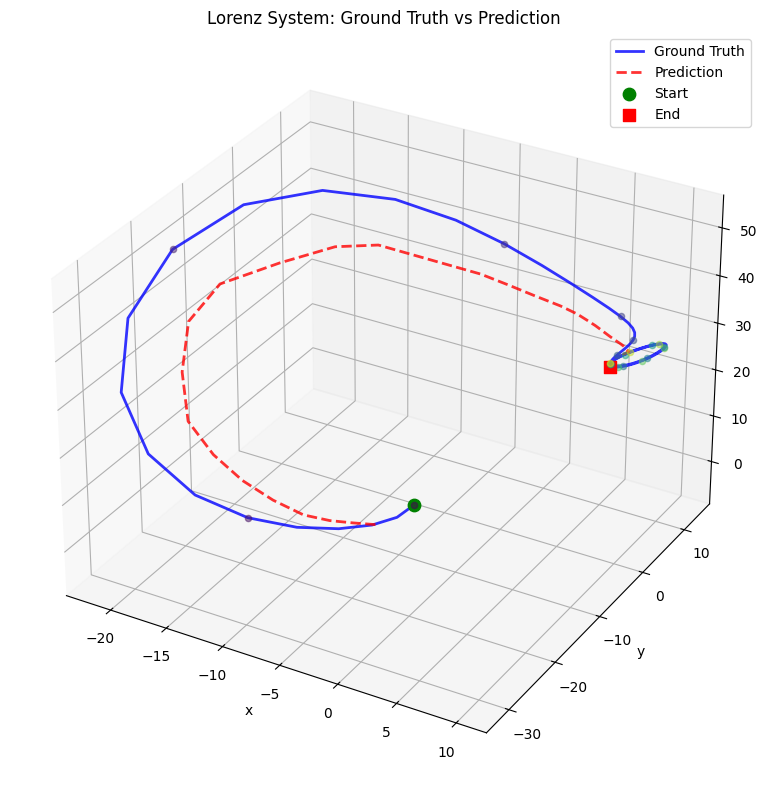


FINAL EVALUATION
Final Test Loss (MSE): 0.163587
Final Test RMSE:       0.404459
Final Test R² Score:   0.837148


In [15]:
"""
STEP 7: VISUALIZE RESULTS (CORREGIDO)
=====================================
Plot training curves and example predictions.
"""

import matplotlib.pyplot as plt
import numpy as np
import torch
from mpl_toolkits.mplot3d import Axes3D  # Para proyección 3D

def plot_training_history(history):
    """
    Plot training and test loss curves.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    ax = axes[0]
    ax.plot(history['train_loss'], 'b-', linewidth=2, label='Train Loss')
    ax.plot(history['test_loss'], 'r-', linewidth=2, label='Test Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title('Training History')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Time per epoch
    ax = axes[1]
    ax.bar(range(len(history['epoch_times'])), history['epoch_times'], alpha=0.7, color='green')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Time (seconds)')
    ax.set_title('Time per Epoch')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_predictions(model, X_test, y_test, scaler_y, device, t_eval, n_samples=3):
    """
    Plot example predictions vs ground truth.
    """
    model.eval()
    
    # Select random samples
    indices = np.random.choice(len(X_test), min(n_samples, len(X_test)), replace=False)
    
    # Crear figura con subplots
    fig = plt.figure(figsize=(14, 5 * n_samples))
    
    with torch.no_grad():
        for row, idx in enumerate(indices):
            # Get data
            x0 = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)  # [1, 3]
            y_true = y_test[idx]  # [seq_len, 3]
            
            # Predict
            pred, _ = model(x0, t_eval)
            pred = pred.squeeze(0).cpu().numpy()  # [num_times, 3]
            
            # Truncate to match sequence length
            seq_len = len(y_true)
            pred = pred[:seq_len]
            
            # Inverse transform to original scale
            y_true_original = scaler_y.inverse_transform(y_true)
            pred_original = scaler_y.inverse_transform(pred)
            
            # Time vector
            dt = 0.02  # Same as used in data generation
            t = np.arange(len(y_true)) * dt
            
            # ---- 3D Trajectory ----
            ax1 = fig.add_subplot(n_samples, 2, 2*row + 1, projection='3d')
            ax1.plot(y_true_original[:, 0], y_true_original[:, 1], y_true_original[:, 2], 
                    'b-', linewidth=2, label='Ground Truth')
            ax1.plot(pred_original[:, 0], pred_original[:, 1], pred_original[:, 2], 
                    'r--', linewidth=2, label='Prediction')
            
            # 🔴 CORREGIDO: Pasar s como argumento con nombre correctamente
            ax1.scatter(y_true_original[0, 0], y_true_original[0, 1], y_true_original[0, 2],
                       c='green', s=50, marker='o', label='Start')
            ax1.scatter(y_true_original[-1, 0], y_true_original[-1, 1], y_true_original[-1, 2],
                       c='red', s=50, marker='s', label='End')
            
            ax1.set_xlabel('x')
            ax1.set_ylabel('y')
            ax1.set_zlabel('z')
            ax1.set_title(f'Trajectory {idx+1}')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # ---- Time Series ----
            ax2 = fig.add_subplot(n_samples, 2, 2*row + 2)
            ax2.plot(t, y_true_original[:, 0], 'r-', label='x (true)', linewidth=1.5, alpha=0.7)
            ax2.plot(t, y_true_original[:, 1], 'g-', label='y (true)', linewidth=1.5, alpha=0.7)
            ax2.plot(t, y_true_original[:, 2], 'b-', label='z (true)', linewidth=1.5, alpha=0.7)
            ax2.plot(t, pred_original[:, 0], 'r--', label='x (pred)', linewidth=1.5, alpha=0.5)
            ax2.plot(t, pred_original[:, 1], 'g--', label='y (pred)', linewidth=1.5, alpha=0.5)
            ax2.plot(t, pred_original[:, 2], 'b--', label='z (pred)', linewidth=1.5, alpha=0.5)
            ax2.set_xlabel('Time')
            ax2.set_ylabel('Value')
            ax2.set_title(f'Time Series {idx+1}')
            ax2.legend(loc='upper right')
            ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_error_analysis(model, X_test, y_test, scaler_y, device, t_eval):
    """
    Plot error analysis: error over time and error distribution.
    """
    model.eval()
    
    all_errors = []
    all_times = []
    
    with torch.no_grad():
        # Select a few samples
        n_samples = min(50, len(X_test))
        indices = np.random.choice(len(X_test), n_samples, replace=False)
        
        for idx in indices:
            x0 = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)
            y_true = y_test[idx]
            
            pred, _ = model(x0, t_eval)
            pred = pred.squeeze(0).cpu().numpy()
            
            seq_len = len(y_true)
            pred = pred[:seq_len]
            
            # Inverse transform
            y_true_original = scaler_y.inverse_transform(y_true)
            pred_original = scaler_y.inverse_transform(pred)
            
            # Compute error per time step (Euclidean distance)
            error = np.sqrt(np.sum((pred_original - y_true_original)**2, axis=1))
            all_errors.append(error)
            all_times.append(np.arange(len(error)) * 0.02)
    
    # Plot error over time
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Error over time (mean ± std)
    ax = axes[0]
    all_errors = np.array(all_errors)
    mean_error = np.mean(all_errors, axis=0)
    std_error = np.std(all_errors, axis=0)
    time_steps = np.arange(len(mean_error)) * 0.02
    
    ax.plot(time_steps, mean_error, 'b-', linewidth=2, label='Mean Error')
    ax.fill_between(time_steps, mean_error - std_error, mean_error + std_error, 
                    alpha=0.3, color='blue', label='±1 Std')
    ax.set_xlabel('Time')
    ax.set_ylabel('Error (Euclidean distance)')
    ax.set_title('Prediction Error over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Error distribution
    ax = axes[1]
    all_errors_flat = all_errors.flatten()
    ax.hist(all_errors_flat, bins=30, alpha=0.7, color='green', edgecolor='black')
    ax.axvline(np.mean(all_errors_flat), color='red', linestyle='--', 
               label=f'Mean: {np.mean(all_errors_flat):.4f}')
    ax.axvline(np.median(all_errors_flat), color='orange', linestyle='--', 
               label=f'Median: {np.median(all_errors_flat):.4f}')
    ax.set_xlabel('Error')
    ax.set_ylabel('Frequency')
    ax.set_title('Error Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nError Statistics:")
    print(f"  Mean Error: {np.mean(all_errors_flat):.6f}")
    print(f"  Std Error:  {np.std(all_errors_flat):.6f}")
    print(f"  Min Error:  {np.min(all_errors_flat):.6f}")
    print(f"  Max Error:  {np.max(all_errors_flat):.6f}")
    print(f"  Median:     {np.median(all_errors_flat):.6f}")

def plot_comparison_3d(model, X_test, y_test, scaler_y, device, t_eval):
    """
    Plot 3D comparison of ground truth and prediction for one trajectory.
    """
    model.eval()
    
    # Select a random sample
    idx = np.random.randint(len(X_test))
    
    with torch.no_grad():
        x0 = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)
        y_true = y_test[idx]
        
        pred, _ = model(x0, t_eval)
        pred = pred.squeeze(0).cpu().numpy()
        
        seq_len = len(y_true)
        pred = pred[:seq_len]
        
        # Inverse transform
        y_true_original = scaler_y.inverse_transform(y_true)
        pred_original = scaler_y.inverse_transform(pred)
    
    fig = plt.figure(figsize=(14, 8))
    
    # 3D trajectory
    ax = fig.add_subplot(111, projection='3d')
    
    # Ground truth
    ax.plot(y_true_original[:, 0], y_true_original[:, 1], y_true_original[:, 2], 
            'b-', linewidth=2, label='Ground Truth', alpha=0.8)
    
    # Prediction
    ax.plot(pred_original[:, 0], pred_original[:, 1], pred_original[:, 2], 
            'r--', linewidth=2, label='Prediction', alpha=0.8)
    
    # Start point
    ax.scatter(y_true_original[0, 0], y_true_original[0, 1], y_true_original[0, 2],
              c='green', s=80, marker='o', label='Start')
    
    # End point
    ax.scatter(y_true_original[-1, 0], y_true_original[-1, 1], y_true_original[-1, 2],
              c='red', s=80, marker='s', label='End')
    
    # Add color gradient for time
    colors = plt.cm.viridis(np.linspace(0, 1, len(y_true_original)))
    for i in range(0, len(y_true_original), 5):
        ax.scatter(y_true_original[i, 0], y_true_original[i, 1], y_true_original[i, 2],
                  c=[colors[i]], s=20, alpha=0.5)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('Lorenz System: Ground Truth vs Prediction')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================
# EXECUTE VISUALIZATIONS
# ============================================

print("\n" + "=" * 60)
print("VISUALIZING RESULTS")
print("=" * 60)

# 1. Plot training history
print("\n1. Plotting training history...")
plot_training_history(history)

# 2. Plot example predictions
print("\n2. Plotting example predictions...")
plot_predictions(model, X_test, y_test, scaler_y, device, t_eval, n_samples=3)

# 3. Plot error analysis
print("\n3. Plotting error analysis...")
plot_error_analysis(model, X_test, y_test, scaler_y, device, t_eval)

# 4. Plot 3D comparison
print("\n4. Plotting 3D comparison...")
plot_comparison_3d(model, X_test, y_test, scaler_y, device, t_eval)

# ============================================
# FINAL EVALUATION
# ============================================
print("\n" + "=" * 60)
print("FINAL EVALUATION")
print("=" * 60)

loss_fn = torch.nn.MSELoss()
final_test_loss, preds, targets = evaluate(
    model, test_loader, loss_fn, device, t_eval
)

print(f"Final Test Loss (MSE): {final_test_loss:.6f}")
print(f"Final Test RMSE:       {np.sqrt(final_test_loss):.6f}")
print(f"Final Test R² Score:   {1 - final_test_loss / np.var(targets):.6f}")
print("=" * 60)